# Artifact-Based Plotting Demo

The following cells demonstrate the new artifact-based plotting workflow:
1. **Generate data** using scripts (one-time)
2. **Plot from saved artifacts** (fast, reproducible)

In [1]:
# Setup: imports and autoreload for development
%load_ext autoreload
%autoreload 2

import plots
from spins_sdp.scripts import exact_ground_energy, npa_energy_lb
from spins_sdp.utils import iter_result_runs, format_result_runs_table

## Step 1: Generate Artifacts (Run Once)

These scripts compute exact ground energies and SDP lower bounds, saving results to disk.
Re-running with `--resume` only computes missing N values.

In [35]:
# Generate exact ground energies for the Ising model
exact_ground_energy.main([
    "--model", "ising",
    "--N-min", "2",
    "--N-max", "12",
    "--J", "1", "--h", "0.7", "--k", "0.3",
    "--boundary", "periodic",
    "--resume",
])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\f0e28cf3d0e38590


0

In [ ]:
# Generate SDP lower bounds
npa_energy_lb.main([
    "--model", "heisenberg",
    "--basis", "heisenberg_simple",
    "--Ns", "2", "3",
    "--boundary", "periodic",
    "--solver", "MOSEK",
    "--resume",
])

Moment relaxation sweep:   0%|          | 0/3 [00:00<?, ?it/s, N=1, done=0, total=3]


ValueError: r must be >= 1.

## Step 2: List Available Runs

Use the `list_runs` utilities to see what artifacts are stored.

In [31]:
# View stored exact ground energy runs
from spins_sdp.utils import list_exact_runs
list_exact_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_exact_ground_ene… v1  aadfb1b072afee7f 12    2026-01-29T12:52:17Z heisenberg     periodic                           


In [59]:
# View stored NPA lower bound runs
from spins_sdp.utils import list_lb_runs
list_lb_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_moment_energy_lb  v1  6bc6edf71cf9c900 4     2026-01-29T13:21:42Z heisenberg     periodic  heisenberg_simple        


## Step 3: Plot from Artifacts

The artifact-based plotting functions load data from saved runs.

### Comparing Exact vs SDP Lower Bound

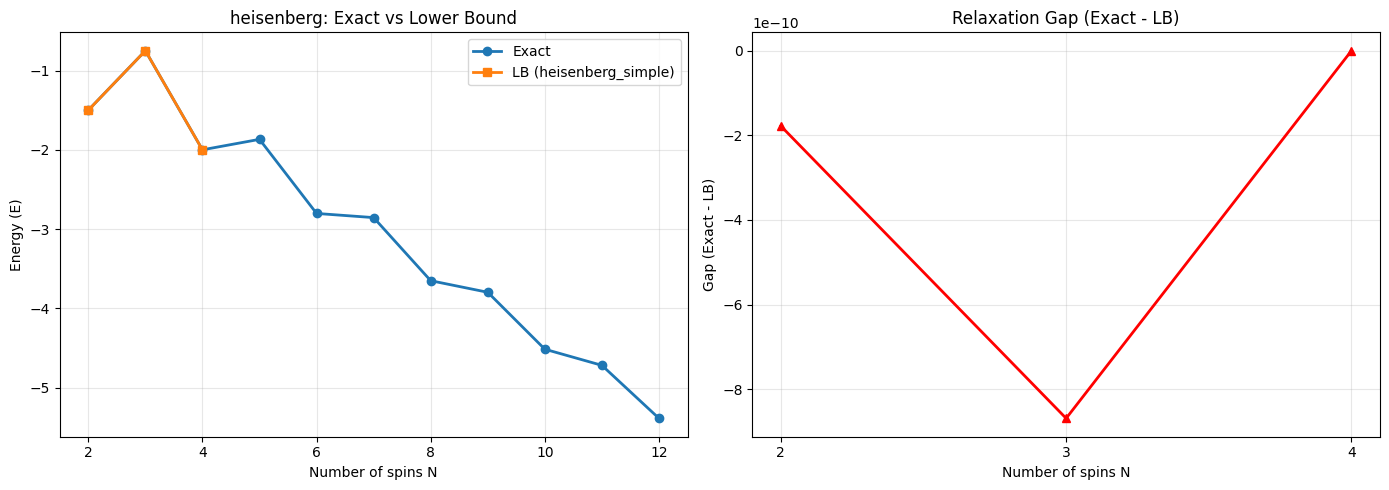

In [63]:
# Plot exact vs NPA lower bound for the Ising model
# Uses parameter-based lookup to find matching artifacts
from plots import plot_exact_vs_lb

_ = plot_exact_vs_lb(
    model="heisenberg",
    model_params={}, #{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
)

### Utility Plots (Computed On-the-Fly)

Some plotting utilities perform quick computations directly without needing stored artifacts.

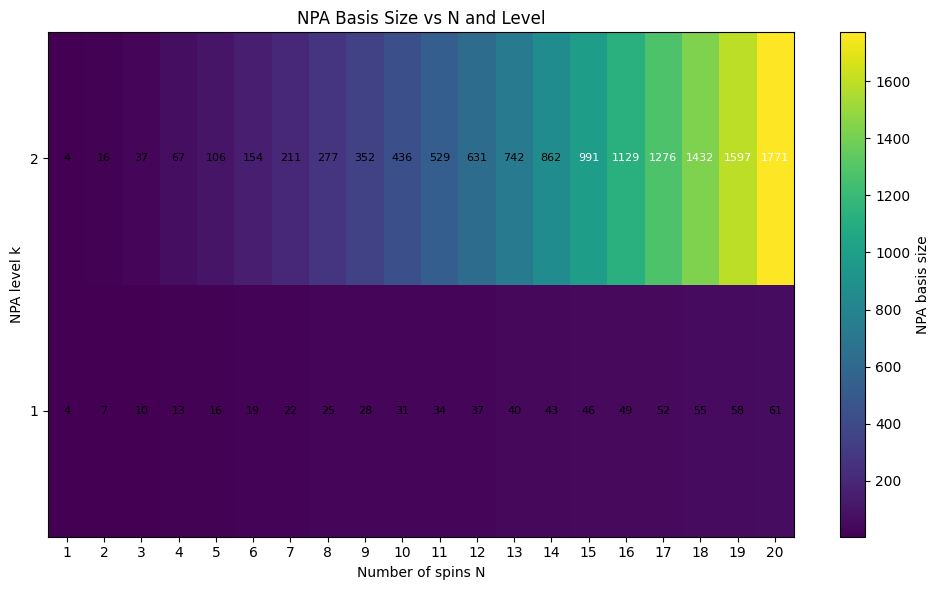

In [9]:
# NPA basis size heatmap: visualize how basis size scales with N and NPA level
from plots import npa_basis_size_heatmap

_ = npa_basis_size_heatmap(N_max=20, npa_level_max=2)

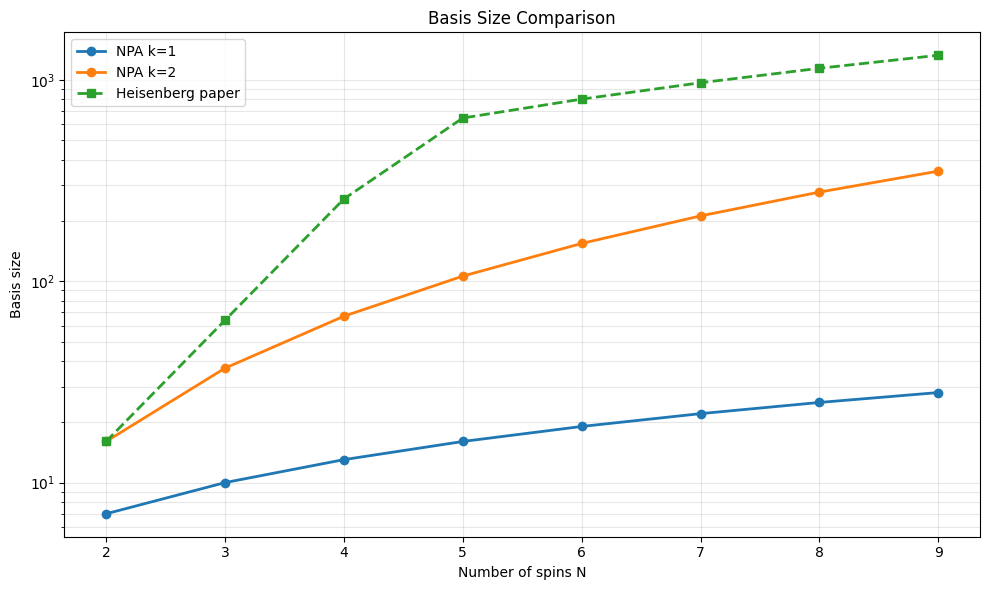

In [53]:
# Compare basis sizes across different methods
from plots import plot_basis_size_comparison

_ = plot_basis_size_comparison(
    N_values=range(2, 10),
    npa_levels=[1, 2],
    include_paper_basis=True,
)

## Runtime Comparison

Compare solve times between exact diagonalization and SDP relaxation.

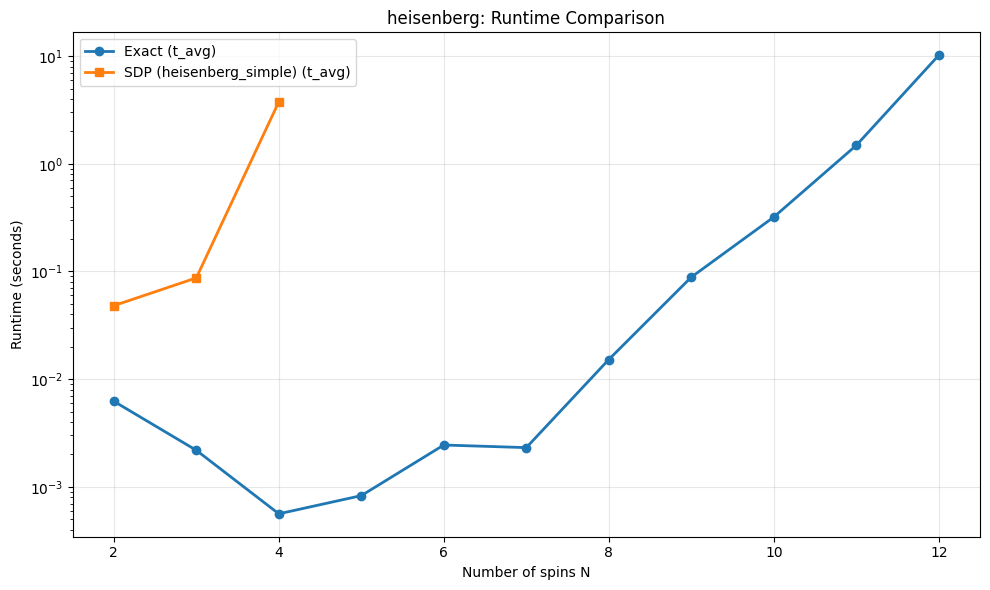

In [64]:
# Plot runtime comparison: Exact diagonalization vs SDP
from plots import plot_runtime_comparison

_ = plot_runtime_comparison(
    model="heisenberg",
    model_params={},#{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
    npa_levels=[1],
    use="t_avg",
    logy=True,
)

## Heisenberg-J₂ Sweep Demo

The `plot_heisenberg_j2_sweep` function plots energy vs J₂ coupling for a fixed N.
First, we need to generate the artifacts for multiple J₂ values.

In [50]:
# Generate Heisenberg-J2 exact ground energies for several J2 values (N=4, small for demo)
J2_values = [0.0, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5]

for J2 in J2_values:
    exact_ground_energy.main([
        "--model", "heisenberg_j2",
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\2b91e99e24e6095a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\af44b6816fc66636
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\04c74a7ae54a1815
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\d5681820b0b0e7ca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\8b64f864e20d738e
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b600d698458f7bca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b452107f935791bc


In [51]:
# Generate SDP lower bounds for the Heisenberg-J2 model
# Using heisenberg_j2_weak basis for J2 <= 1.0, heisenberg_j2_strong for J2 > 1.0

for J2 in J2_values:
    basis = "heisenberg_j2_weak" if J2 <= 1.0 else "heisenberg_j2_strong"
    npa_energy_lb.main([
        "--model", "heisenberg_j2",
        "--basis", basis,
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--solver", "MOSEK",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\3c384c07a34e0516
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\eb81c2d0fb7595db
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\274fe120f45c7051
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\5b5a8d554997eeed
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\2476d7561f5c559a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\e2e4158a6576ad8b
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\71f3e03227592f66


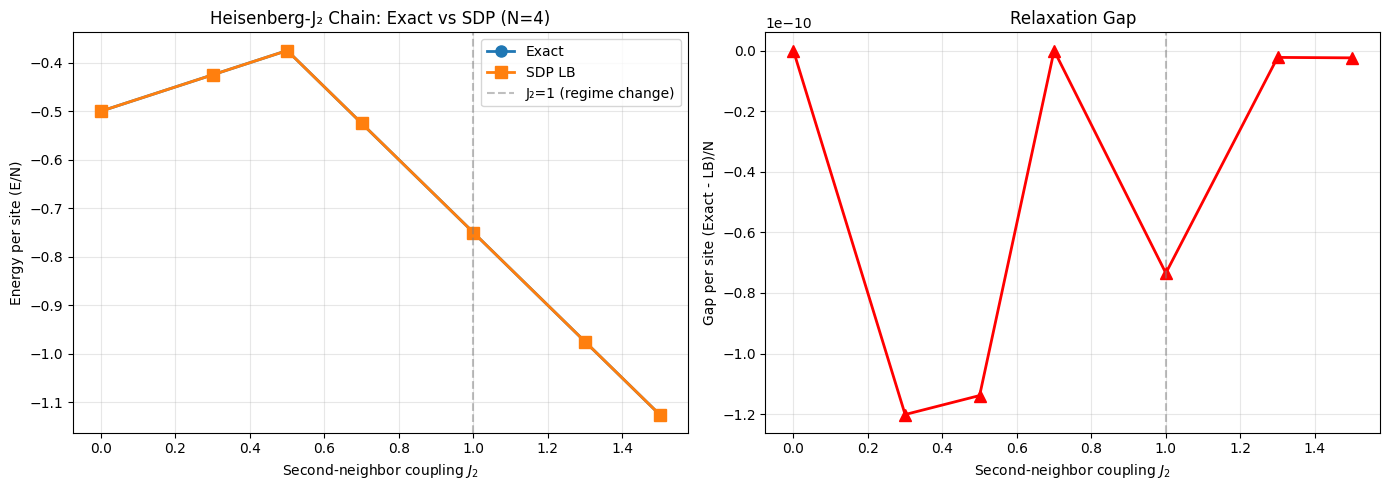

Heisenberg-J₂ Chain (N=4) - Exact vs SDP Comparison
J2         Exact E         SDP LB          Gap             Gap/N           Basis               
----------------------------------------------------------------------------------------------------
0.000      -2.00000000     -2.00000000     -8.65973959e-15 -2.16493490e-15 heisenberg_j2_weak  
0.300      -1.70000000     -1.70000000     -4.80385287e-10 -1.20096322e-10 heisenberg_j2_weak  
0.500      -1.50000000     -1.50000000     -4.55319338e-10 -1.13829834e-10 heisenberg_j2_weak  
0.700      -2.10000000     -2.10000000     -4.88498131e-15 -1.22124533e-15 heisenberg_j2_weak  
1.000      -3.00000000     -3.00000000     -2.93762792e-10 -7.34406980e-11 heisenberg_j2_weak  
1.300      -3.90000000     -3.90000000     -9.07540709e-12 -2.26885177e-12 heisenberg_j2_strong
1.500      -4.50000000     -4.50000000     -9.66604574e-12 -2.41651144e-12 heisenberg_j2_strong


In [52]:
# Plot Heisenberg-J2 sweep
from plots import plot_heisenberg_j2_sweep

_ = plot_heisenberg_j2_sweep(
    N=4,
    J2_values=J2_values,
    boundary="periodic",
    per_site=True,
)

## Summary (Exact & SDP Artifacts)

General workflow for exact/SDP results:

1. **Generate Artifacts** – Run scripts (`exact_ground_energy`, `npa_energy_lb`) to compute and save results with `--resume` for incremental updates.
2. **List Runs** – Use `list_exact_runs()` and `list_lb_runs()` to inspect stored data.
3. **Plot from Artifacts** – Call plotting functions to visualize results without recomputation:
   - `plot_exact_vs_lb()` – Compare exact vs SDP lower bound
   - `plot_runtime_comparison()` – Compare solve times
   - `plot_heisenberg_j2_sweep()` – Energy vs J₂ coupling
4. **Utility Plots** – Quick on-the-fly visualizations:
   - `npa_basis_size_heatmap()` – Heatmap of basis sizes
   - `plot_basis_size_comparison()` – Compare basis methods

---

# Optimization Sweep Demo

This section demonstrates the **optimization sweep** functionality, which uses the optimization package to find optimal subsets of monomials to add to a starting NPA basis.

## The Problem

Given:
- A **starting set** of monomials (e.g., NPA level 1)
- An **adding set** of candidate monomials (difference between NPA level 2 and level 1)
- A **Hamiltonian** to minimize

We want to find which **k monomials** from the adding set give the best SDP lower bound.

This is a combinatorial optimization problem with $\binom{L}{k}$ possible choices, where $L = |\text{adding set}|$.

## Step 1: Run an Optimization Sweep

The `optimization_sweep` script runs Monte Carlo optimization for multiple values of k (number of monomials to add) and multiple random seeds, saving all results to disk.

### CLI Usage

```bash
# Basic usage with simulated annealing
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --ks 0 1 2 3 4 5 \
    --seeds 42 43 44

# Or sweep k from 0 to k-max (inclusive)
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --k-max 10 --num-seeds 3
```

### Getting help (list all args)

To see all available command-line arguments (including `--method`-specific options), run:

```bash
python -m spins_sdp.scripts.optimization_sweep --help
# or
python -m spins_sdp.scripts.optimization_sweep -h
```

If you have multiple Python installations, make sure you’re using your project environment’s interpreter. In this repo that’s typically:

```bash
C:/.../code/SpinsSDP/.venv/Scripts/python.exe -m spins_sdp.scripts.optimization_sweep -h
```

### Programmatic Usage (in notebook)

In [25]:
# Run optimization sweep programmatically
from spins_sdp.scripts import optimization_sweep

# Run a small sweep
optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "10",
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-level", "2",
    "--method", "sa",
    "--sa-steps", "50",
    "--ks", "6", "8", "10",
    "--bo-n-init", "3",
    "--bo-n-iter", "10",
    "--num-seeds", "3",
    "--resume",  # Skip already-computed runs
])

Model: heisenberg, N=10, boundary=periodic
Starting set size: 31, Adding set size: 405, Final set size: 436
Total jobs: 9, Already done: 30, To compute: 9


Optimization sweep: 100%|██████████| 9/9 [01:10<00:00,  7.78s/it, k=10, seed=44]


Results saved to: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/3b12db9ce9962758
Total runs: 39
Results saved to: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/3b12db9ce9962758


0

## Step 2: List Available Optimization Runs

Use `list_optimization_runs()` to see what optimization sweeps are stored.

In [36]:
# List all optimization sweep runs
from plots import list_optimization_runs

runs = list_optimization_runs()

Hash               Model          N Method    L         k  Runs Updated             
--------------------------------------------------------------------------------
23a81bbbc21dafc8   heisenberg    10 random  405     0..10   550 2026-01-29T13:01:47 
2e02e6acf19e09e9   heisenberg     8     pt  252     0..10    22 2026-01-29T12:59:33 
6eaa0eb9533ae44d   heisenberg     4     sa   54     0..10    22 2026-01-29T12:53:20 
713ae9244c97fa6d   heisenberg     8     bo  252     0..10    22 2026-01-29T13:00:26 
80886b435b17c6e5   heisenberg    10     pt  405     0..10    22 2026-01-29T13:04:32 
8be9fe9005d6a2a0   heisenberg     6 random  135     0..10   550 2026-01-29T12:55:02 
a40f1c66e9e85893   heisenberg     4     bo   54     0..10    22 2026-01-29T12:54:22 
a89e15e73a165584   heisenberg     8     sa  252     0..10    22 2026-01-29T12:58:15 
b5e1d1e567b83d47   heisenberg     4     pt   54     0..10    22 2026-01-29T12:53:50 
dec53bc75dbf7fbf   heisenberg     6     pt  135     0..10    22 2026-

## Step 3: Plot Optimization Results

### Main Plot: Lower Bound vs Number of Monomials

The primary visualization shows how the SDP lower bound improves as we add more monomials to the basis.

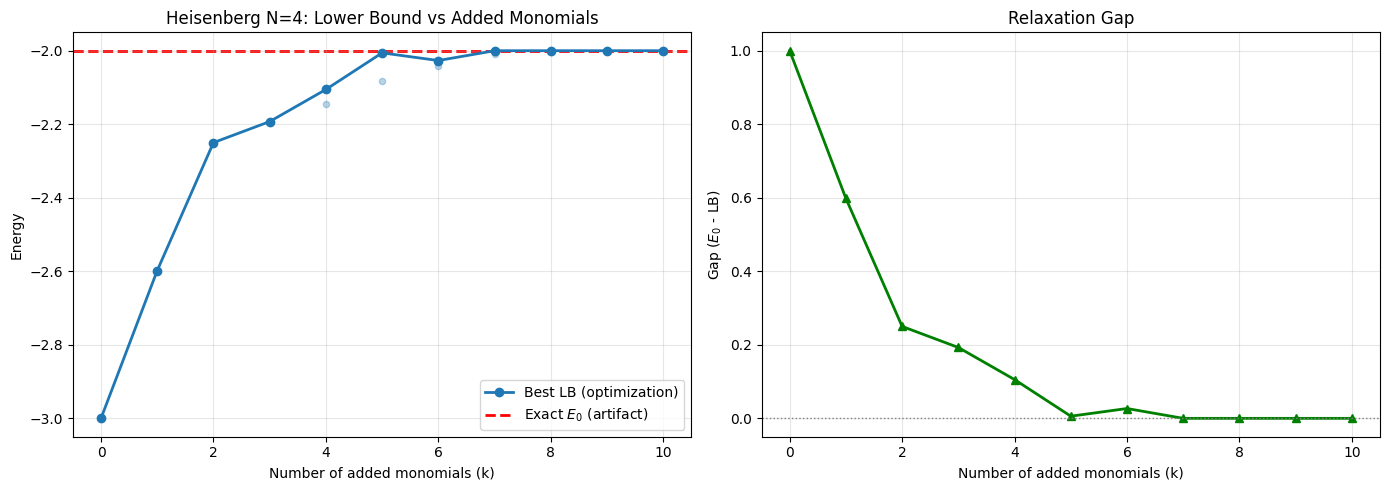

Adding set size (L): 54


In [65]:
# Plot optimization sweep results
# The function automatically finds the exact ground state energy for comparison
from plots import plot_optimization_sweep

result = plot_optimization_sweep(
    model="heisenberg",
    N=4,
    boundary="periodic",
    start_level=1,
    end_level=2,
    method="pt",
    show_seeds=True,  # Show individual seed results as scatter points
)

print(f"Adding set size (L): {result['L']}")

### Convergence Analysis

How quickly does the lower bound approach the full relaxation value as we add monomials?

[WARN] Full-relaxation LB artifact not found (or missing requested N); skipping full-relaxation line and relative-improvement panel. model='heisenberg' N=4 boundary='periodic' end_level=2 solver='MOSEK' mosek_tol=1e-09 params={}


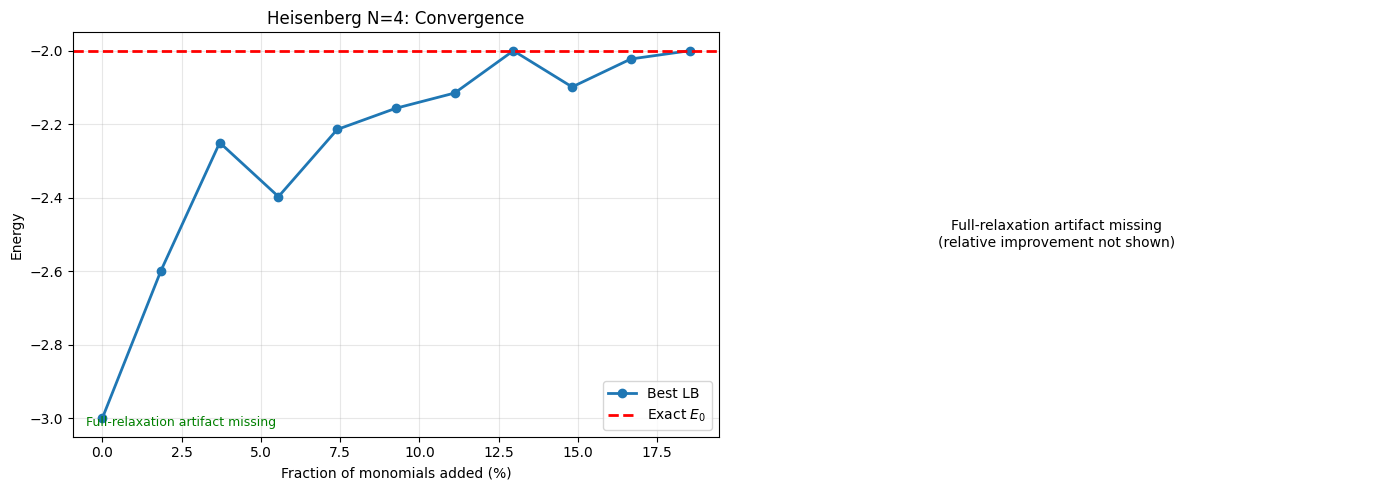

In [66]:
# Plot convergence: normalized improvement vs fraction of monomials
from plots import plot_optimization_convergence

_ = plot_optimization_convergence(
    model="heisenberg",
    N=4,
    boundary="periodic",
    start_level=1,
    end_level=2,
    method="sa",
)

### Seed Variability Analysis

Compare optimization results across different random seeds to understand reliability.

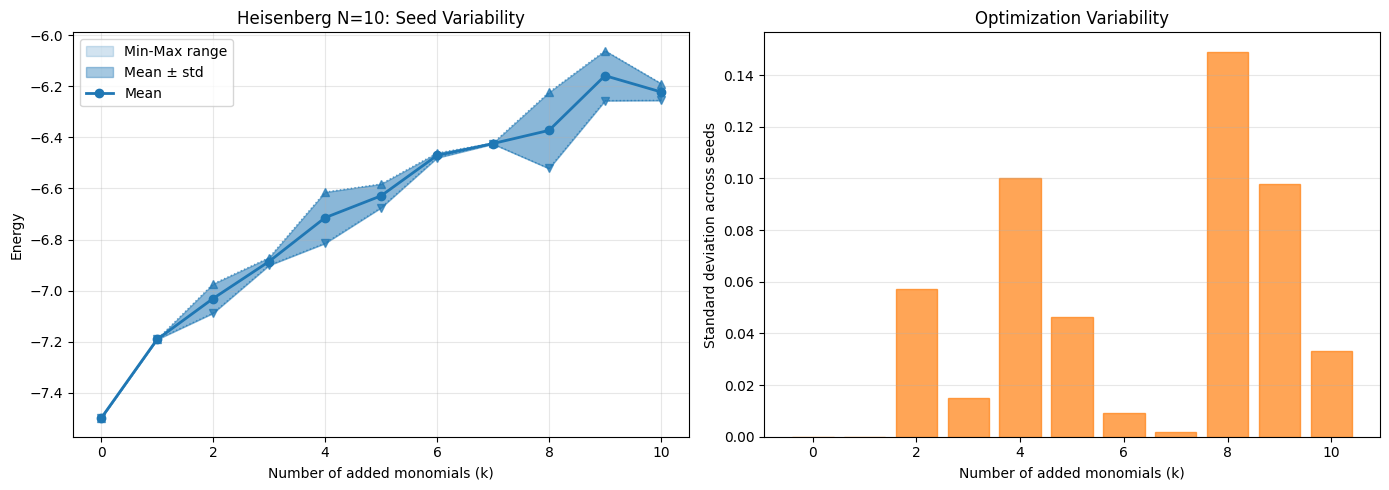

In [47]:
# Plot seed comparison: mean ± std and variability across seeds
from plots import plot_optimization_seeds_comparison

_ = plot_optimization_seeds_comparison(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    method="bo",
)

### Random Sampling Baseline

To validate that the optimization is actually finding better solutions than random chance, we run a **random sampling baseline**. This picks k monomials randomly (without any optimization) and evaluates the SDP.

#### Running Random Sampling

```bash
# Run random sampling with the same settings as optimization
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method random \
    --k-max 16 --num-seeds 10
```

The random baseline uses `--method random` and evaluates each random selection once (no optimization steps).

In [29]:
# Run random sampling baseline
from spins_sdp.scripts import optimization_sweep

optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "10",
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-level", "2",
    "--method", "random",  # Random sampling
    "--k-max", "10",
    "--num-seeds", "10",   # More seeds for statistical power
    "--resume",
])

Model: heisenberg, N=10, boundary=periodic
Starting set size: 31, Adding set size: 405, Final set size: 436
Total jobs: 110, Already done: 0, To compute: 110


Optimization sweep: 100%|██████████| 110/110 [00:15<00:00,  7.13it/s, k=10, seed=51]



Results saved to: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/23a81bbbc21dafc8
Total runs: 110
Results saved to: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/23a81bbbc21dafc8


0

### Optimization vs Random Comparison

**Is optimization actually finding better solutions than random sampling?**

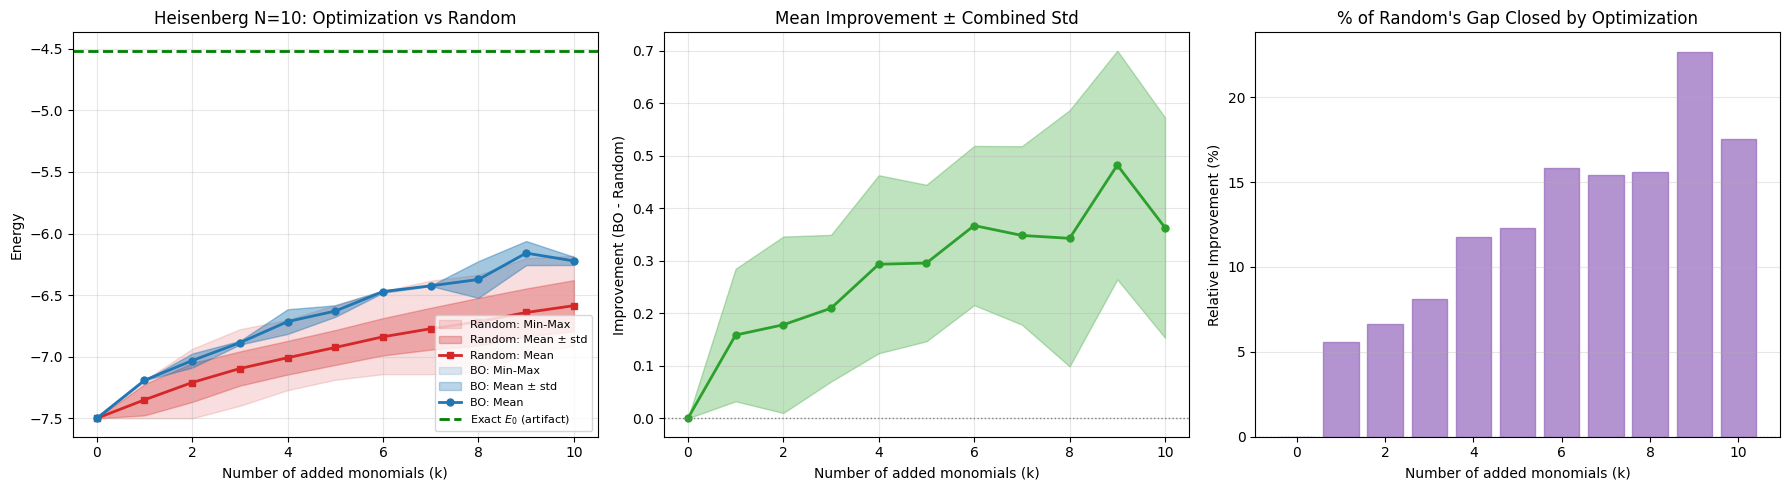


Comparison Summary:
  Common k values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]
  Mean improvement at k=8: 0.342687
  Relative improvement at k=8: 15.6%


In [50]:
# Compare optimization vs random sampling
from plots import plot_optimization_vs_random

comparison = plot_optimization_vs_random(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    optimization_method="bo",  # Compare SA optimization vs random
)

# Print summary statistics
print(f"\nComparison Summary:")
print(f"  Common k values: {list(comparison['common_ks'])}")
print(f"  Mean improvement at k=8: {comparison['improvement']['mean'][8]:.6f}")
print(f"  Relative improvement at k=8: {comparison['improvement']['relative_percent'][8]:.1f}%")

### Multi-Method Comparison

When we have multiple optimization methods (SA, PT, BO) plus random sampling, we can compare them all at once:

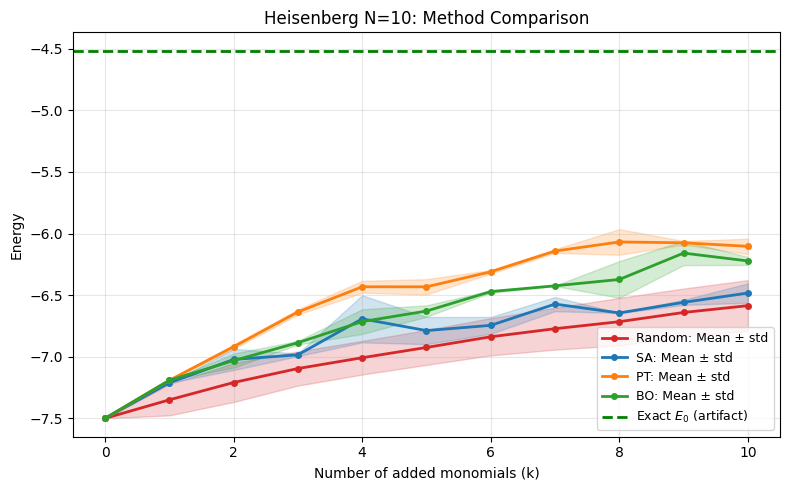

Methods compared: ['random', 'sa', 'pt', 'bo']


In [54]:
# Compare all available methods
from plots import plot_method_comparison

try:
    method_comparison = plot_method_comparison(
        model="heisenberg",
        N=10,
        boundary="periodic",
        start_level=1,
        end_level=2,
        methods=["random", "sa", "pt", "bo"],  # Will skip methods without data
    )
    print(f"Methods compared: {method_comparison['methods']}")
except FileNotFoundError as e:
    print(f"Note: {e}")
    print("Run more optimization methods to see a full comparison.")

### Timing Analysis

How long does each optimization take?

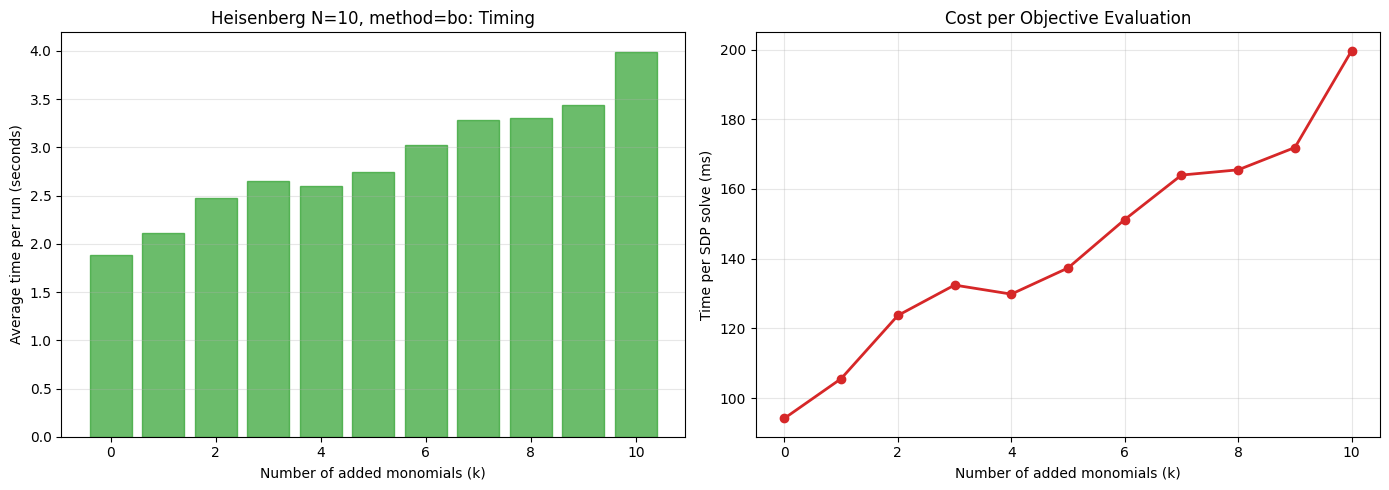

In [57]:
# Plot timing information
from plots import plot_optimization_timing

_ = plot_optimization_timing(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    method="bo",
)

## Step 4: Load Raw Results

We can also load the raw data directly for custom analysis.

In [81]:
# Load results as DataFrame
from spins_sdp.scripts.optimization_sweep import results_to_dataframe, get_best_per_k, load_optimization_results
from pathlib import Path

run_root = Path("spins_sdp/results/spin_optimization_sweep/v1")
run_dirs = []
p = run_root
if p.exists():
    run_dirs.extend([d for d in p.iterdir() if d.is_dir()])

run_dirs = sorted(run_dirs, key=lambda d: d.stat().st_mtime, reverse=True)

if run_dirs:
    run_dir = run_dirs[0]

    # Load as DataFrame
    df = results_to_dataframe(run_dir)
    print("DataFrame of all runs:")
    print(df.head(10))
    print(f"\nTotal runs: {len(df)}")
else:
    print("No optimization sweep runs found under spins_sdp/results/spin_optimization_sweep/v1.")


DataFrame of all runs:
   run_idx  k  seed  best_value  elapsed_s  n_obj_evals
0        0  0    42   -3.000000   0.020915           51
1        1  0    43   -3.000000   0.013634           51
2        2  0    44   -3.000000   0.013850           51
3        3  0    45   -3.000000   0.012515           51
4        4  0    46   -3.000000   0.012518           51
5        5  1    42   -2.598076   0.771376           51
6        6  1    43   -2.598076   0.755477           51
7        7  1    44   -2.598076   0.765626           51
8        8  1    45   -2.598076   0.775141           51
9        9  1    46   -2.598076   0.749787           51

Total runs: 85


In [82]:
# Get best result for each k (across all seeds)
if run_dirs:
    best_per_k = get_best_per_k(run_dir)
    print("Best value per k:")
    for k, info in sorted(best_per_k.items()):
        print(f"  k={k}: value={info['best_value']:.6f}, seed={info['seed']}")

Best value per k:
  k=0: value=-3.000000, seed=42
  k=1: value=-2.598076, seed=42
  k=2: value=-2.250000, seed=43
  k=3: value=-2.121320, seed=46
  k=4: value=-2.112042, seed=45
  k=5: value=-2.057930, seed=46
  k=6: value=-2.059560, seed=45
  k=7: value=-2.000000, seed=42
  k=8: value=-2.000000, seed=45
  k=9: value=-2.000000, seed=45
  k=10: value=-2.000000, seed=45
  k=11: value=-2.000000, seed=43
  k=12: value=-2.000000, seed=42
  k=13: value=-2.000000, seed=44
  k=14: value=-2.000000, seed=44
  k=15: value=-2.000000, seed=44
  k=16: value=-2.000000, seed=44


In [84]:
# Access the selected monomials (masks)
if run_dirs:
    import numpy as np
    results = load_optimization_results(run_dir, unpack_masks=True)
    masks = results["data"]["masks"]  # Boolean array of shape (n_runs, L)
    data = results["data"]
    
    print(f"Masks shape: {masks.shape}")
    print(f"First run selected {int(masks[0].sum())} monomials out of {masks.shape[1]}")
    print(f"Selection mask: {masks[0].astype(int)}")
    
    print()
    
    k_max = int(np.max(data['k']))
    idxs = np.where(data['k'] == k_max)[0]
    if len(idxs) > 0:
        j = int(idxs[np.argmax(data['best_value'][idxs])])
        print(f"Best at max k={k_max}: idx={j}, seed={int(data['seed'][j])}, best_value={float(data['best_value'][j]):.6f}")
        print(f"Selected {int(masks[j].sum())} monomials; mask: {masks[j].astype(int)}")

Masks shape: (85, 54)
First run selected 0 monomials out of 54
Selection mask: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Best at max k=16: idx=82, seed=44, best_value=-2.000000
Selected 16 monomials; mask: [0 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0]


## Optimization Sweep Summary

The general workflow:

1. **Run Sweep** – Use `optimization_sweep` script or `compute_and_save()` function
   - Supports multiple methods:
     - `--method sa` – Simulated annealing
     - `--method pt` – Parallel tempering
     - `--method bo` – Bayesian optimization
     - `--method random` – Random sampling baseline
   - Results are saved incrementally with `--resume` support
   - Stores selected monomials as bit-packed masks

2. **List Runs** – Use `list_optimization_runs()` to see available sweeps
   - Filter by model or method: `list_optimization_runs(method="sa")`

3. **Visualize** – Multiple plotting functions:
   - `plot_optimization_sweep()` – Main plot: LB vs k with exact energy reference
   - `plot_optimization_convergence()` – How quickly does the LB converge?
   - `plot_optimization_seeds_comparison()` – Variability across seeds
   - `plot_optimization_timing()` – Timing analysis
   - **`plot_optimization_vs_random()`** – Compare optimization vs random baseline
   - **`plot_method_comparison()`** – Compare multiple methods side-by-side

4. **Load Data** – For custom analysis:
   - `results_to_dataframe()` – Get pandas DataFrame
   - `get_best_per_k()` – Get best result per k value
   - `load_optimization_results()` – Get full data including masks

---

# DMRG Upper Bounds

The `dmrg` script runs DMRG for multiple system sizes, saving results to disk with the same artifact-based pattern as the other scripts.

**Note:** DMRG with PBC requires **N ≥ 4**. Smaller systems will be automatically skipped.

### CLI Usage

```bash
# Heisenberg model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg --N-min 4 --N-max 16 \
    --chi-max 256 --mixer --resume

# Ising model
python -m spins_sdp.scripts.dmrg \
    --model ising --Ns 6 8 10 12 \
    --J 1.0 --h 0.5 \
    --chi-max 128 --mixer --resume

# Heisenberg-J2 model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg_j2 --Ns 8 10 12 \
    --J2 0.5 --chi-max 512 --mixer --resume
```

### Programmatic Usage (in notebook)

In [3]:
# Note: DMRG with PBC requires N >= 4 (two-site update constraint)
from spins_sdp.scripts import dmrg

# Run DMRG for Heisenberg model
dmrg.main([
    "--model", "heisenberg",
    "--N-min", "4",
    "--N-max", "10",
    "--chi-max", "128",
    "--mixer",
    "--resume",
])

Model: heisenberg, boundary=periodic
DMRG params: chi_max=128, mixer=True, combine=False
Requested N: [4, 5, 6, 7, 8, 9, 10]
Already computed: []
To compute: [4, 5, 6, 7, 8, 9, 10]


DMRG sweep:   0%|          | 0/7 [00:00<?, ?it/s, N=4, done=0, total=7]c:\Users\lmatos\Desktop\code\SpinsSDP\.venv\Lib\site-packages\tenpy\networks\mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)
DMRG sweep:  14%|█▍        | 1/7 [00:00<00:00,  8.38it/s, N=5, done=1, total=7]c:\Users\lmatos\Desktop\code\SpinsSDP\.venv\Lib\site-packages\tenpy\networks\mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar 


Results saved to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\d6a08aa1f18196a6
Total N values: 7
Results saved to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\d6a08aa1f18196a6


0

`list_dmrg_runs()` to see what DMRG results are stored.

In [4]:
from spins_sdp.scripts.dmrg import list_dmrg_runs

runs = list_dmrg_runs()
print(f"Found {len(runs)} DMRG run(s):\n")
for run in runs:
    print(f"  Model: {run['model']}, chi_max={run['chi_max']}, mixer={run['mixer']}")
    print(f"  N values: {run.get('Ns_present', [])}")
    print(f"  Path: {run['_run_dir']}")
    print()

Found 2 DMRG run(s):

  Model: heisenberg, chi_max=128, mixer=True
  N values: [4, 5, 6, 7, 8, 9, 10]
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\d6a08aa1f18196a6

  Model: heisenberg, chi_max=64, mixer=True
  N values: []
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\e8570fa916ecad9d



Load DMRG results for custom analysis.

In [5]:
# Load DMRG results from the most recent run
from spins_sdp.scripts.dmrg import load_dmrg_results
from pathlib import Path

run_root = Path("spins_sdp/results/spin_dmrg_energy_ub/v1")
if run_root.exists():
    run_dirs = sorted([d for d in run_root.iterdir() if d.is_dir()], 
                      key=lambda d: d.stat().st_mtime, reverse=True)
    if run_dirs:
        run_dir = run_dirs[0]
        results = load_dmrg_results(run_dir)
        
        print("DMRG Results:")
        print(f"Model: {results['meta']['model']}")
        print(f"chi_max: {results['meta']['chi_max']}, mixer: {results['meta']['mixer']}")
        print()
        print(f"{'N':>4} {'E (total)':>14} {'e (per site)':>14} {'chi_final':>10} {'time (s)':>10}")
        print("-" * 56)
        for N in sorted(results['data'].keys()):
            d = results['data'][N]
            print(f"{N:4d} {d['E']:14.8f} {d['e']:14.8f} {d['chi_final']:10d} {d['elapsed_s']:10.2f}")
else:
    print("No DMRG runs found. Run the cell above first.")

DMRG Results:
Model: heisenberg
chi_max: 128, mixer: True

   N      E (total)   e (per site)  chi_final   time (s)
--------------------------------------------------------
   4    -2.00000000    -0.50000000          4       0.10
   5    -1.86803399    -0.37360680          4       0.90
   6    -2.80277564    -0.46712927          8       0.21
   7    -2.85517926    -0.40788275          8      47.22
   8    -3.65109341    -0.45638668         16       0.35
   9    -3.79729978    -0.42192220         16       0.60
  10    -4.51544635    -0.45154464         32       0.52
